## This code computes the linear memory capacity of RC
"""
Linear Memory Capacity (MC) Description

1. Setup
---------
- Input: scalar time series u(t), typically a random sequence (e.g., i.i.d. uniform or Gaussian).
- Desired output for each delay k:
    y_k(t) = u(t - k)
- Reservoir state at time t:
    x(t) ∈ ℝ^N

2. Linear Readout Training for Each Delay k ∈ [1, K]
----------------------------------------------------
- Train a linear readout:
    ŷ_k(t) = w_k^T x(t)
  to predict y_k(t) = u(t - k).

- Compute coefficient of determination R_k^2 between y_k(t) and ŷ_k(t):
  
    R_k^2 = [Cov(y_k, ŷ_k)]² / (Var(y_k) Var(ŷ_k))

  This measures how well the reservoir recalls the input delayed by k steps.

3. Memory Capacity (MC)
-----------------------
- Total memory capacity is the sum over delays:
  
    MC = ∑_{k=1}^K R_k^2

- Theoretical upper bound:
  
    MC ≤ N

  where N is the number of reservoir nodes.

References:
- Jaeger, H. "Short term memory in echo state networks," GMD Report 152, 2001.
- White, O. L., Lee, D. D., & Sompolinsky, H. "Short-term memory in orthogonal neural networks," Phys. Rev. Lett., 92(14), 2004.
"""

# 1. Load Pruning RC data

In [1]:
import numpy as np
import seaborn as sns
import os
from matplotlib import pyplot as plt
import pickle
import pandas as pd

from helpers_models import model_config_from_experiment
from cpsmehelper import export_figure
from plotting import (
    plot_loss_histories,
    plot_property_histories,
    plot_violin_comparison,
    plot_property_histories_till_best,
    plot_loss_histories,
    plot_loss_histories_till_best,
)


# Add the directory containing the style file to the matplotlib style path
plt.style.use(os.path.join(os.getcwd(), "AIP_journal.mplstyle"))
FIGURE_PATH = os.path.join(os.getcwd(), "figures")

# Select the case to analyse
CASE = "all"  # give a specific case name or "all" to analyse all cases

# Load the data
def load_data(CASE):
    SAVE_NAME = f"{CASE}.pkl"
    SAVE_PATH = os.path.join(os.getcwd(), "stored_results", SAVE_NAME)

    # load experiment configuration
    # Define RC properties for the models that will later be pruned
    rc_config = model_config_from_experiment(experiment_name=CASE)
    dataset = rc_config["dataset"]
    identifier = rc_config["identifier"]
    DATA_FILE = os.path.join(os.getcwd(), "stored_results", f"{CASE}.pkl")

    # load data
    with open(DATA_FILE, "rb") as file:
        data = pickle.load(file)    
    return data

In [2]:
data = load_data("SC1B1")
data.keys()

dict_keys(['data_train', 'data_test', 'rc_config', 'models', 'scores', 'graph_props', 'models_pruned', 'scores_pruned', 'graph_props_pruned', 'pruning_histories'])

delay: 4


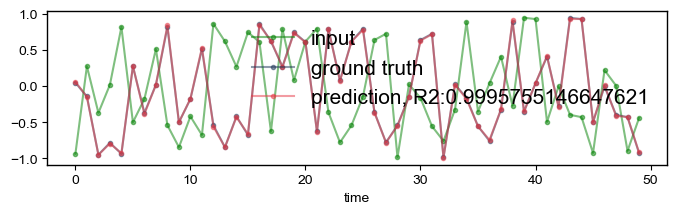

delay: 8


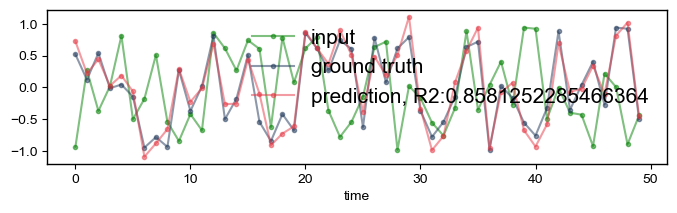

delay: 12


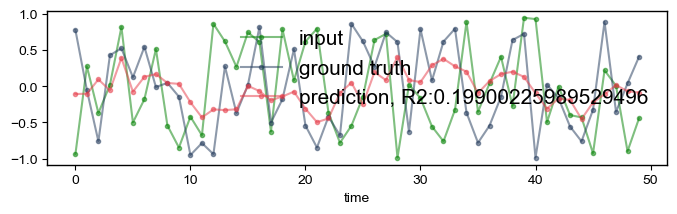

Linear Memory Capacity: 13.463507331793187


In [5]:
def generate_input(T, input_scale=1.0, seed=42):
    np.random.seed(seed)
    return np.random.uniform(-input_scale, input_scale, T)

def RC_run(RC_model, x):
    num_nodes = RC_model.reservoir_layer.nodes
    activation = RC_model.reservoir_layer.activation_fun
    alpha = RC_model.reservoir_layer.leakage_rate  # leakage rate
    A = RC_model.reservoir_layer.weights  # reservoir weight matrix (adjacency matrix)
    W_in = RC_model.input_layer.weights  # read-in weight matrix
    
    n_time = x.shape[0]
    states = np.zeros((n_time+1, num_nodes))
    states[0, :] = RC_model.reservoir_layer.initial_res_states
    
    ### Compute input contributions
    input_contrib = (W_in*x.T).T  
    
    for t in range(n_time):
        reservoir_contrib = np.matmul(A, states.T).T
        states[t + 1,:] = (1 - alpha)*states[t,:] + alpha * activation(reservoir_contrib[t,:] + input_contrib[t,:])
    return states


def Ridge_Regression(R, gamma, V_train):
    I = np.identity(R.shape[1])
    return V_train.T @ R @ np.linalg.inv(R.T @ R + gamma * I) 

def compute_linear_memory_capacity(input_signal, RC_model, gamma, delay_max=100):
    from sklearn.metrics import r2_score

    Transients=delay_max
    MC = 0.0
    X = input_signal.reshape(1, -1)
    Xn = X[:,Transients:]
    r = RC_run(RC_model, input_signal)[Transients:,:]
    
    for k in range(1, delay_max + 1):
        Yk = np.roll(input_signal, k).reshape(1, -1)[:,Transients:]
        ###ridge regression fit
        Wout = Ridge_Regression(r[1:, :], gamma, Yk.T)
        Yk_pred = (Wout @ r[1:, :].T)

        ###Memory Capacity
        R2 = r2_score(Yk[0], Yk_pred[0])
        MC += R2

        ####plot after every 10 steps
        if k%4==0 and k < 15:
            print('delay:', k)
            # plt.figure()
            plt.figure(figsize=(8, 2))
            plt.plot(Xn[0,:50], label='input', marker='.', color='green',alpha=0.5)
            plt.plot(Yk[0,:50], label='ground truth', marker='.', color='#1D3557',alpha=0.5)
            plt.plot(Yk_pred[0,:50], label=f'prediction, R2:{R2}', marker='.', color='#E63946', alpha=0.5)
            plt.legend(fontsize=15, loc='upper right')
            plt.xlabel('time')
            plt.show()
    return MC


gamma = 5e-8
T = 2000

u = generate_input(T, input_scale=1, seed=42)
RC_run(data["models"][5], u.reshape(-1, 1)).shape

mc = compute_linear_memory_capacity(u, data["models"][5], gamma, delay_max=100)
print("Linear Memory Capacity:", mc)

In [5]:
# List of cases
case_group = ["SC1A1", "SC1A2", "SC1B1", "SC1B2", "SC1C1", "SC1C2", "SC3A1", "SC3A2", "SC3B1", "SC3B2", 
              "SC3C1", "SC3C2", "N5A1", "N5A2", "N5B1", "N5B2", "N5C1", "N5C2", "N10A1", "N10A2", 
              "N10B1", "N10B2", "N10C1", "N10C2", "N15A1", "N15A2", "N15B1", "N15B2", "N15C1", "N15C2"]

# Initialize an empty list to collect the results for each case
all_percentage_changes = []

# Loop through each case in case_group
for case in case_group:
    # Load data for each case
    data = load_data(case)
    
    # Get initial and pruned graph properties
    graph_props = data["graph_props"]
    graph_props_pruned = data["graph_props_pruned"]
    
    # Initialize a dictionary to store percentage changes for each property
    case_percentage_changes = {'case': case}

    # Loop through each graph property and calculate percentage change
    for i in range(len(graph_props)):
        # Calculate percentage change for each property
        density_change = ((graph_props_pruned[i]['density'] - graph_props[i]['density']) / graph_props[i]['density']) * 100
        spectral_radius_change = ((graph_props_pruned[i]['spectral_radius'] - graph_props[i]['spectral_radius']) / graph_props[i]['spectral_radius']) * 100
        av_in_degree_change = ((graph_props_pruned[i]['av_in_degree'] - graph_props[i]['av_in_degree']) / graph_props[i]['av_in_degree']) * 100
        av_out_degree_change = ((graph_props_pruned[i]['av_out_degree'] - graph_props[i]['av_out_degree']) / graph_props[i]['av_out_degree']) * 100
        clustering_coefficient_change = ((graph_props_pruned[i]['clustering_coefficient'] - graph_props[i]['clustering_coefficient']) / graph_props[i]['clustering_coefficient']) * 100
        
        # Add the percentage changes to the dictionary
        case_percentage_changes['density'] = density_change
        case_percentage_changes['spectral_radius'] = spectral_radius_change
        case_percentage_changes['av_in_degree'] = av_in_degree_change
        case_percentage_changes['av_out_degree'] = av_out_degree_change
        case_percentage_changes['clustering_coefficient'] = clustering_coefficient_change

    # Append the case's percentage changes to the results list
    all_percentage_changes.append(case_percentage_changes)

# Convert the list of results into a DataFrame
df_percentage_changes = pd.DataFrame(all_percentage_changes)

df_percentage_changes

,case,density,spectral_radius,av_in_degree,av_out_degree,clustering_coefficient
0,SC1A1,4.225752,-10.362914,-8.536585,-8.536585,-2.409590
1,SC1A2,0.729777,-4.180960,-5.437352,-5.437352,3.030669
2,SC1B1,0.604933,-1.795274,-2.114119,-2.114119,-10.667545
3,SC1B2,0.112831,-7.841229,-6.651550,-6.651550,0.619501
4,SC1C1,2.770619,-0.660436,-0.343643,-0.343643,0.837073
5,SC1C2,1.201219,-5.713143,-5.954422,-5.954422,3.896817
6,SC3A1,9.530262,-4.215095,-8.352230,-8.352230,50.381770
7,SC3A2,-0.229775,-11.982644,-10.410410,-10.410410,-4.903494
8,SC3B1,3.665865,-11.284095,-10.343035,-10.343035,-5.583323
9,SC3B2,2.181718,-2.170056,-1.960784,-1.960784,-0.996014
